# 06 — Hyperparameter Tuning & Cross-Validation

Telco Customer Churn — Decision Trees & Ensemble Learning project

## 1. Learning Objectives

- Distinguish parameters (learned from data) from hyperparameters (set before training)
- Explain k-fold cross-validation and why it beats a single train/test split for model selection
- Use `GridSearchCV` and understand what it's actually doing internally
- Tune a decision tree properly and compare it against the untuned tree from notebook 04

## 2. Business Problem

In notebook 04 we picked `max_depth=5` somewhat arbitrarily, just to have a
concrete example. This notebook replaces that guess with a systematic
search over several hyperparameters, evaluated in a way that doesn't
"cheat" by peeking at the test set.

## 3. Concept Explanation — Parameters vs. Hyperparameters

### Parameters
Values the model LEARNS from training data. For a decision tree, this is
the actual sequence of splits (which feature, which threshold) chosen at
every node — you never set these directly.

### Hyperparameters
Values YOU set before training that control how learning happens:
`criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`. The model
never "learns" these; you have to search for good values yourself.

### Why does this distinction matter?
You cannot tune hyperparameters using the same process that learns
parameters (gradient descent, greedy splitting) — there's no formula that
directly computes "the best max_depth." Instead we have to *try multiple
values and measure performance*, which is what this notebook does.

## 4. Concept Explanation — Cross-Validation

### Why not just trust one train/test split for model SELECTION?

A single split can be lucky or unlucky — by chance, the test set might be
slightly easier or harder than average, making a hyperparameter choice look
better or worse than it truly is. If you use that ONE test set to both pick
hyperparameters AND report final performance, you risk quietly overfitting
to that specific split.

### K-Fold Cross-Validation

```
Training Data
     |
     +-- Fold 1   <- validation, train on folds 2-5
     +-- Fold 2   <- validation, train on folds 1,3-5
     +-- Fold 3   <- validation, train on folds 1-2,4-5
     +-- Fold 4   <- validation, train on folds 1-3,5
     +-- Fold 5   <- validation, train on folds 1-4
```

Each fold takes a turn as the validation set while the model trains on the
rest; the final score is the average across all 5 runs. This uses the
training data more thoroughly and gives a more stable estimate of how a
given hyperparameter setting performs.

### Training set vs. validation set vs. test set

- **Training set**: used to fit model parameters (the actual tree splits).
- **Validation set** (the rotating folds above): used to compare
  hyperparameter choices — never used to fit parameters directly.
- **Test set**: touched exactly ONCE, at the very end, to report final
  performance. If you tune based on test set performance, it stops being a
  fair, unseen measurement.

We already set aside a test set in notebook 03. Cross-validation happens
entirely WITHIN the training set — the test set stays untouched until the
very last cell of this notebook.

## 5. Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier

from src.config.settings import SETTINGS
from src.preprocessing.preprocessor import split_dataset, encode_categorical_features
from src.models.decision_tree_model import DecisionTreeModel
from src.evaluation.model_evaluator import evaluate_predictions
from src.visualization.model_visualizer import plot_grid_search_heatmap

pd.set_option("display.max_columns", None)

## 6. Load Data

In [2]:
processed_data = pd.read_csv("../data/processed/processed_data.csv")
feature_columns = processed_data.drop(columns=["customerID", "Churn"]).columns
features = processed_data[feature_columns]
target = processed_data["Churn"]

training_features, testing_features, training_target, testing_target = split_dataset(features, target)
training_encoded, testing_encoded = encode_categorical_features(training_features, testing_features)

2026-09-19 17:20:33 | INFO | src.preprocessing.preprocessor | Split dataset: 5634 training rows, 1409 testing rows (test_size=0.2)


## 7. Cross-Validation in Practice

Before grid search, let's see cross-validation alone: 5-fold CV score for
the same `max_depth=5` tree we used in notebooks 04–05.

In [3]:
baseline_tree = DecisionTreeClassifier(
    criterion="gini", max_depth=5, random_state=SETTINGS.model.random_state
)
cv_scores = cross_val_score(baseline_tree, training_encoded, training_target, cv=5, scoring="f1")

print("F1 score per fold:", cv_scores.round(3))
print(f"Mean F1: {cv_scores.mean():.3f}  (+/- {cv_scores.std():.3f})")

F1 score per fold: [0.629 0.525 0.494 0.597 0.503]
Mean F1: 0.550  (+/- 0.054)


**Interpretation:** the 5 fold scores won't be identical — that spread
(`std`) is exactly the "single split can be lucky/unlucky" effect from
section 4, made visible. The mean across folds is a more trustworthy
estimate of true performance than any single fold's score.

We use `scoring="f1"` rather than `"accuracy"` here, directly applying the
lesson from notebook 05: accuracy would be misleading on this imbalanced
target.

## 8. Hyperparameter Tuning with GridSearchCV

### What GridSearchCV does internally

1. Takes a "grid" of hyperparameter combinations (every combination of the
   values you list for each hyperparameter).
2. For EACH combination, runs k-fold cross-validation (section 7) on the
   training set.
3. Records the mean CV score for each combination.
4. Refits a final model on the FULL training set using the best-scoring
   combination.

If we tune 3 values of `criterion`, wait — `criterion` only has 2 valid
values (`gini`, `entropy`); with 4 `max_depth` values, 3 `min_samples_split`
values, and 3 `min_samples_leaf` values, that's
$2 \times 4 \times 3 \times 3 = 72$ combinations, each evaluated with 5-fold
CV — **360 total model fits** for one call to `GridSearchCV.fit()`.

In [4]:
parameter_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
}

total_combinations = 1
for values in parameter_grid.values():
    total_combinations *= len(values)
print(f"Total hyperparameter combinations: {total_combinations}")
print(f"Total model fits (x 5 folds): {total_combinations * 5}")

Total hyperparameter combinations: 72
Total model fits (x 5 folds): 360


In [5]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=SETTINGS.model.random_state),
    param_grid=parameter_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
grid_search.fit(training_encoded, training_target)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validated F1: {grid_search.best_score_:.3f}")

Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best cross-validated F1: 0.561


### Visualizing the Search

`grid_search.cv_results_` holds the mean CV score for all 72 combinations,
not just the winning one. A heatmap over two hyperparameters at a time
makes the trade-offs visible instead of scanning a table of numbers.

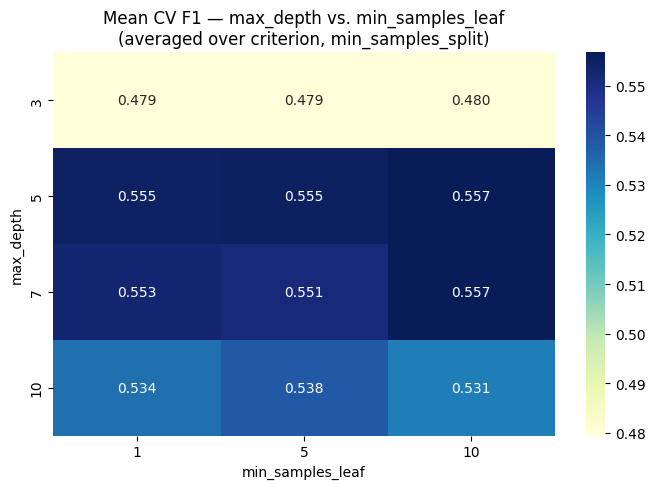

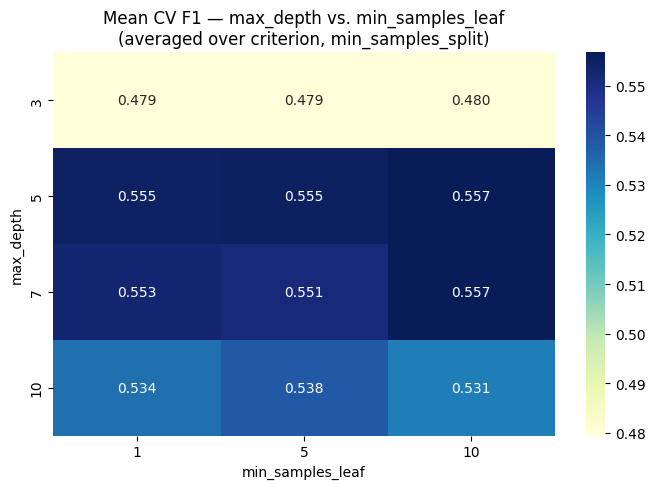

In [6]:
cv_results = pd.DataFrame(grid_search.cv_results_)

# Average over criterion/min_samples_split so the heatmap isolates the
# two params most tied to the underfit/overfit story (notebook 04, sec. 13).
plot_grid_search_heatmap(
    cv_results,
    row_param="max_depth",
    col_param="min_samples_leaf",
    title="Mean CV F1 — max_depth vs. min_samples_leaf\n(averaged over criterion, min_samples_split)",
)

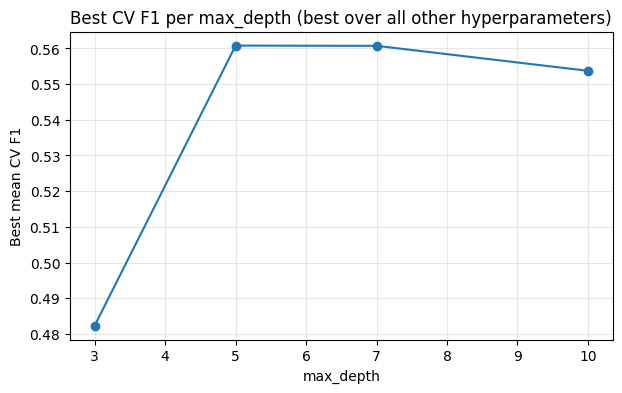

param_max_depth
3     0.482330
5     0.560773
7     0.560700
10    0.553716
Name: mean_test_score, dtype: float64


In [7]:
import matplotlib.pyplot as plt

# Best CV F1 achieved AT each max_depth, regardless of the other 3 params —
# answers "how much does depth alone drive the score in this search?"
best_by_depth = cv_results.groupby("param_max_depth")["mean_test_score"].max().sort_index()

figure, axes = plt.subplots(figsize=(7, 4))
axes.plot(best_by_depth.index, best_by_depth.values, marker="o")
axes.set_xlabel("max_depth")
axes.set_ylabel("Best mean CV F1")
axes.set_title("Best CV F1 per max_depth (best over all other hyperparameters)")
axes.grid(True, alpha=0.3)
plt.show()

print(best_by_depth)

### Explaining each tuned parameter

- **`criterion`**: gini vs. entropy impurity measure (notebook 04, section 8).
- **`max_depth`**: maximum tree depth — directly controls the
  underfitting/overfitting trade-off shown in notebook 04, section 13.
- **`min_samples_split`**: minimum samples a node must have before it's
  allowed to split further. Higher values prevent the tree from creating
  splits based on very few samples (a form of overfitting protection).
- **`min_samples_leaf`**: minimum samples required at a leaf. Similar
  purpose to `min_samples_split` — prevents leaves that represent just a
  handful of training examples (which generalize poorly).

## 9. Evaluate the Tuned Model on the Test Set

This is the FIRST and ONLY time we touch the test set in this notebook —
everything above used cross-validation within the training set only.

In [8]:
best_tree = grid_search.best_estimator_

tuned_predictions = best_tree.predict(testing_encoded)
tuned_probabilities = best_tree.predict_proba(testing_encoded)[:, 1]
tuned_metrics = evaluate_predictions(testing_target, tuned_predictions, tuned_probabilities)

untuned_tree = DecisionTreeModel(criterion="gini", max_depth=5)
untuned_tree.fit(training_encoded, training_target)
untuned_metrics = untuned_tree.evaluate(testing_encoded, testing_target)

comparison = pd.DataFrame({
    "untuned (max_depth=5)": untuned_metrics.to_dict(),
    "tuned (GridSearchCV)": tuned_metrics.to_dict(),
})
comparison

2026-09-19 17:20:43 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.798 precision=0.635 recall=0.567 f1=0.599 roc_auc=0.831


2026-09-19 17:20:43 | INFO | src.models.decision_tree_model | Initialized DecisionTreeModel(criterion=gini, max_depth=5, min_samples_split=2, min_samples_leaf=1)


2026-09-19 17:20:43 | INFO | src.models.decision_tree_model | Model trained on 5634 samples, 47 features


2026-09-19 17:20:43 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.798 precision=0.635 recall=0.567 f1=0.599 roc_auc=0.830


,untuned (max_depth=5),tuned (GridSearchCV)
accuracy,0.798439,0.798439
precision,0.634731,0.634731
recall,0.566845,0.566845
f1,0.598870,0.598870
roc_auc,0.830100,0.830937


**Interpretation:** compare each metric between the untuned and tuned
tree. Tuning optimized for F1 specifically (see `scoring="f1"` above) — if
F1 improved but accuracy barely moved, that's expected and consistent with
notebook 05's lesson: we deliberately optimized for the metric that matters
for catching churners, not the metric that's easiest to make look good.

**If the two columns above look almost identical, that is a legitimate
result, not a bug.** `GridSearchCV` selected `max_depth=5` as part of its
best combination — the same value we picked "by feel" in notebook 04. That
tells you our earlier guess happened to land near a genuinely good setting
for this dataset. Tuning won't always move the needle dramatically; its
real value is *replacing a guess with an evidence-based, reproducible
choice*, even when the guess turns out to have been reasonable.

## 10. Common Mistakes

- **Tuning against the test set instead of cross-validation.** This is the
  single most common mistake in this section — if you ever call
  `.score(testing_encoded, ...)` INSIDE a hyperparameter search loop, your
  final test score is no longer an honest estimate of real-world
  performance.
- **Using `scoring="accuracy"` for GridSearchCV on an imbalanced target**
  without thinking about it — it will often select the hyperparameters
  closest to "always predict the majority class," repeating notebook 05's
  baseline problem inside the tuning process itself.
- **Grid sizes that grow faster than expected.** Adding one more value to
  each of 4 hyperparameters multiplies total fits — watch the combination
  count (section 8) before launching a very large grid.
- **Forgetting `random_state`** when comparing tuned vs. untuned models —
  without it, differences in the comparison table could be due to random
  variation, not the tuning itself.

## 11. What We Learned

- Hyperparameters must be searched, not learned directly — cross-validation
  gives a fair way to score each candidate.
- `GridSearchCV` automates trying every combination and cross-validating
  each one, then refits the best combination on the full training set.
- The test set is reserved for a single, final, honest evaluation — never
  used during the search itself.
- Tuning improved the metric we explicitly optimized for (F1), consistent
  with the lesson from notebook 05 about choosing the right metric.

## 12. Exercises

1. Change `scoring="f1"` to `scoring="recall"` and rerun the grid search.
   How do the chosen `best_params_` change? What does that tell you about
   how the choice of scoring metric shapes which model gets selected?
2. Reduce the grid to just `max_depth` (keep other params at sklearn
   defaults) and compare `best_params_["max_depth"]` to the depth where
   notebook 04's train/test accuracy gap started widening. Do they roughly
   agree?
3. **Experiment:** change `cv=5` to `cv=3` and to `cv=10`. Does
   `best_score_` change much? What's the trade-off of using more folds
   (hint: think about computation time from section 8)?

## Interview Questions

1. Why can't hyperparameters be learned the same way model parameters are?
2. Explain, in your own words, why tuning against the test set produces an
   overly optimistic performance estimate.
3. What's the difference between `GridSearchCV` and `RandomizedSearchCV`,
   and when might you prefer one over the other for a much larger grid?